# Envolventes de resistencia al corte

© 2022 Exneyder A. Montoya-Araque, Daniel F. Ruiz y Universidad EAFIT.

Este notebook puede ejecutarse en línea → [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AppliedMechanics-EAFIT/slope_stability/blob/main/notebooks/01_cond_factors/strength_envelopes.ipynb)

La implementación sigue el análisis de fallas superficiales en taludes de suelo presentado por {cite:t}`Lade_2010_MechanicsSurficialFailure`.

## Fundamentos

La envolvente de Mohr–Coulomb aproxima la resistencia mediante $\tau_f=c'+\sigma'_n\tan\phi'$. En materiales no lineales, una única pareja $(c',\phi')$ depende del intervalo de esfuerzos usado para ajustar la recta; por ello conviene comparar la envolvente curva y sus aproximaciones secantes o tangentes.

## Cómo usar la herramienta

1. Defina los parámetros del modelo y el intervalo de esfuerzo normal pertinente.
2. Compare la envolvente no lineal con los ajustes lineales mostrados.
3. Use parámetros efectivos o totales de manera consistente con el problema.
4. No extrapole la envolvente fuera del intervalo calibrado.

## Módulos requeridos y configuración de figuras

In [1]:
import ast # helps with converting str representation of python data structures
import numpy as np
from scipy import optimize
from numpy.polynomial.polynomial import polyfit, Polynomial
import matplotlib.pyplot as plt
import matplotlib as mpl
from ipywidgets import widgets as wgt
from IPython import get_ipython
from IPython.display import display

if 'google.colab' in str(get_ipython()):
    print('Running in Google Colab. Installing the required modules...')
    from subprocess import run
    # run('pip install ipympl', shell=True);
    from google.colab import output
    output.enable_custom_widget_manager()

# Figure style shared by every chapter
plt.style.use("default")
AXIS_LINEWIDTH = 1.25
PLOT_LINEWIDTH = 1.75
mpl.rcParams.update(
    {
        "figure.constrained_layout.use": False,
        "figure.figsize": (6.4, 4.2),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "DejaVu Serif",
        "font.serif": ["DejaVu Serif"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "axes.linewidth": AXIS_LINEWIDTH,
        "axes.formatter.use_mathtext": True,
        "axes.unicode_minus": False,
        "lines.linewidth": PLOT_LINEWIDTH,
        "lines.markersize": 6,
        "grid.color": "0.75",
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "legend.frameon": False,
        "mathtext.fontset": "dejavuserif",
        "xtick.major.width": AXIS_LINEWIDTH,
        "ytick.major.width": AXIS_LINEWIDTH,
        "text.usetex": False,
    }
)

In [2]:
# def fit_curved_env(σ, τ, p_atm=100):
#     τ_log_nor = np.log(τ/p_atm)
#     σ_log_nor = np.log(σ/p_atm)
#     log_a, b = polyfit(σ_log_nor, τ_log_nor, deg=1)
#     return np.exp(log_a), b

def f_power(σ, a, b):
    return a * 100 * (σ / 100) ** b

def fit_env(σ, τ, intercept=None, power=False, lade=False):
    if power:
        if lade:
            m, b = fit_env(np.log10(σ/100), np.log10(τ/100))
            a, b = 10**(m/100 + b), m  #m, np.exp(b)#np.exp(inter)
        else:
            a, b = optimize.curve_fit(f_power, σ, τ)[0]
        return a, b
    if intercept is None:
        A = np.vstack([σ, np.ones(len(σ))]).T
        m, b = np.linalg.lstsq(A, τ, rcond=None)[0]
    else:
        A = np.vstack([σ, np.zeros(len(σ))]).T
        m, b = np.linalg.lstsq(A, τ-intercept, rcond=None)[0][0], intercept
    return m, b

def strength_envelope(σ, τ, curved_env=False, tan_curved_env=False,
                      σ_star=150, widget=False, **kwargs):
    p_atm = kwargs.get('p_atm', 100)
    if type(σ) == str:  # This is for interpreting in from the widget
        σ = ast.literal_eval(f"[{σ}]")
    if type(τ) == str:  # This is for interpreting in from the widget
        τ = ast.literal_eval(f"[{τ}]")
    min_id = min(len(σ), len(τ))
    σ, τ = np.array(σ[:min_id]), np.array(τ[:min_id])
    # Mohr-Coulomb envelope as linear fit of all the points
    # c, tan_𝜙 = polyfit(σ, τ, deg=1)
    tan_𝜙, c = fit_env(σ, τ, intercept=None, power=False)
    if c < 0:
        tan_𝜙, c = fit_env(σ, τ, intercept=0, power=False)
    # tan_𝜙 = np.tan(𝜙)
    𝜙 = np.degrees(np.arctan(tan_𝜙))
    linear_env_MC = Polynomial([c, tan_𝜙])
    # Power function envelope (Lade, 2010)
    # a, b = fit_curved_env(σ, τ, p_atm)
    a, b = fit_env(σ, τ, power=True, lade=True)
    curved_env_eq = lambda σ_n: a * p_atm * (σ_n/p_atm) ** b

    # stress vs horizontal deformation plot
    σ_plot = np.linspace(0, 1.2 * max(σ), 100)
    fig = plt.figure(figsize=kwargs.get('figsize', [7, 4]))
    ax = fig.add_subplot(111)
    label = "$\\tan(" + f"{𝜙:.1f}" + "^\\circ )\\sigma_\\mathrm{n}$"
    if c > 0:
        label = "$\\tau=" + f"{c:.1f}$+" + label
    ax.plot(σ_plot, linear_env_MC(σ_plot), ls="-", color="k", label=label)
    if curved_env:
        ax.plot(σ_plot, curved_env_eq(σ_plot), ls="--", color='b',
            label="$\\tau=" + f"{a:.2f}" + "P_\\mathrm{a}\\left("
            + "\\frac{\\sigma}{P_\\mathrm{a}}\\right)^{" + f"{b:.2f}" + "}$")
    if tan_curved_env:
        tan_𝜙_tan = a * b * (σ_star/p_atm) ** (b-1)
        𝜙_tan = np.degrees(np.arctan(tan_𝜙_tan))
        c_tan = curved_env_eq(σ_star) - tan_𝜙_tan*σ_star
        linear_env_tan_curved_env = Polynomial([c_tan, tan_𝜙_tan])
        ax.plot(σ_plot, linear_env_tan_curved_env(σ_plot), ls="--", color='r',
            label="$\\tau^\\star=" + f"{c_tan:.1f}"
            + "+\\tan(" + f"{𝜙_tan:.1f}" + "^\\circ )\\sigma_\\mathrm{n}$")
        ax.plot(σ_star, curved_env_eq(σ_star), ls="", marker="*", ms=10,
                color='k')#, label="$\\sigma_\\mathrm{n}^\\star$")
    ax.plot(σ, τ, ls='', marker="o", mec='k', mfc='w', ms=7,
            label='Data')
    ax.set_xlabel("normal stress, $\\sigma_\\mathrm{n}$   [$\\mathrm{kPa}$]")
    ax.set_ylabel("shear stress $\\tau$   [$\\mathrm{kPa}$]")
    tau_max = max(τ)
    ax.axis("image")
    ax.set_ylim(
        (0, max(tau_max, linear_env_MC(σ_plot[-1]), curved_env_eq(σ_plot[-1]))))
    ax.set_xlim((0, σ_plot[-1]))
    ax.grid(True, ls="--", lw=0.5)
    ax.spines["bottom"].set_linewidth(AXIS_LINEWIDTH)
    ax.spines["left"].set_linewidth(AXIS_LINEWIDTH)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
    return

# strength_envelope(σ=[100, 200, 400], τ=[80, 145, 250], curved_env=True,
#                   tan_curved_env=True, σ_star=50)
# strength_envelope(σ=[100, 200, 400], τ=[80, 145, 250], curved_env=True,
#                   tan_curved_env=True, σ_star=0.01)

In [3]:
# Interactive figure
s, l = {'description_width': '200'}, wgt.Layout(width='450px')
s_tan, l_tan = {'description_width': '5'}, wgt.Layout(width='320px')
controls = {
    'σ': wgt.Text(value="48.9, 97.8, 244.5", description="𝜎ₙ", style=s, layout=l),
    'τ': wgt.Text(value="38.2, 57.1, 89.2", description="𝜏ₙ", style=s, layout=l),
    'curved_env': wgt.Checkbox(value=False, description="Plot power function fitting?", style=s, layout=l),
    'tan_curved_env': wgt.Checkbox(value=False, description="Plot tangent to power fit at 𝜎ₙ★?", style=s_tan, layout=l_tan),
    'σ_star': wgt.FloatSlider(value=75, min=0.1, max=250, step=0.2, description="𝜎ₙ★", style=s_tan, layout=wgt.Layout(width='300px')),
    'widget': wgt.Checkbox(value=True, description='Non-vector image (improve widget performance)', style=s, layout=l)
}
c_all = list(controls.values())
c_tan = [wgt.HBox(c_all[3:5])]
c = c_all[:3] + c_tan + c_all[5:]
fig = wgt.interactive_output(strength_envelope, controls)
wgt.HBox((wgt.VBox(c), fig), layout=wgt.Layout(align_items='center'))

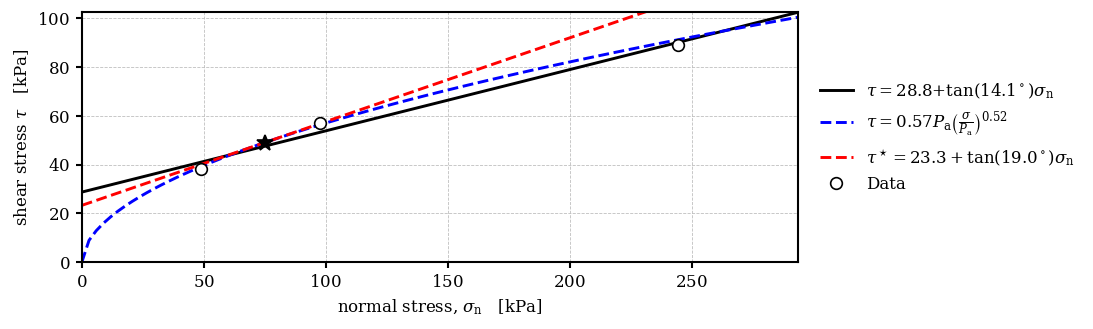

In [4]:
# Non-interactive figure
strength_envelope(
    σ=[48.9, 97.8, 244.5],
    τ=[38.2, 57.1, 89.2],
    curved_env=True,
    tan_curved_env=True,
    σ_star=75,
    figsize=[9, 3]
)